In [148]:
from spar import basicFunction, readBasicFunctions, kineticMapping, potentialMapping
import importlib

importlib.reload(spar)
import numpy as np
import re
import matplotlib.pyplot as plt
%matplotlib inline

### KEO Demo
Below we illustrate how SPAR is used to return the $G$ matrix and pseudopotential $U$ of an A2BC type molecule at a single point such that it might be evaluated using multi-dimensional quadrature. 

We highlight how the same checkpoint file and basic functions are usable for both H2CS and H2CO, merely by changing the masses and as such is valid for all molecules of the same structure. 

In [73]:
toRadians = np.pi/180.0

# Case of H2CS
masses = np.array([12.00000000, 31.9720707, 1.00782503223, 1.00782503223])
# Geometry we wish to evaluate KEO at for quadrature (single-point calculation)
internalCoordinates = np.array([1.608952, 1.086848, 1.086848, 121.750*toRadians, 121.750*toRadians, np.pi])

# Read basic functions for A2BC type molecule
basicFunctions = readBasicFunctions("KEO/A2BC/combination.chk")

# Read KEO checkpoint
keoMapping = kineticMapping("KEO/A2BC/kinetic.chk")
# Evaluate returns specified component component
keoMapping.evaluate("gvib", basicFunctions, internalCoordinates, masses)
keoMapping.evaluate("grot", basicFunctions, internalCoordinates, masses)
keoMapping.evaluate("gcor", basicFunctions, internalCoordinates, masses)
keoMapping.evaluate("pseudo", basicFunctions, internalCoordinates, masses)

# To switch to H2CO all we need is to change masses
masses = np.array([12.00000000, 15.99491463, 1.00782503223, 1.00782503223])
# Geometry we wish to evaluate KEO at for quadrature (single-point calculation)
internalCoordinates = np.array([1.203374200, 1.103774652, 1.103774652, 2.12658330381800, 2.12658330381800, np.pi])
keoMapping.evaluate("gvib", basicFunctions, internalCoordinates, masses)
keoMapping.evaluate("grot", basicFunctions, internalCoordinates, masses)
keoMapping.evaluate("gcor", basicFunctions, internalCoordinates, masses)
keoMapping.evaluate("pseudo", basicFunctions, internalCoordinates, masses) 

np.float64(-16.12726266663172)

In [100]:
# HCO+ potential from Winterhoff et al 2018
internalCoordinates = [2.017, 2.393, 0]

basicFunctions = readBasicFunctions("Potentials/HCO+/combination.chk")
basicFunctions[1][2].evaluate(internalCoordinates[0])

np.float64(0.0)

In [ ]:
pesMapping = potentialMapping("Potentials/HCO+/potential.chk")
pesMapping.potentialBasicFunctionIndices

array([[0, 0, 1],
       [0, 0, 2],
       [0, 0, 3],
       [1, 0, 1],
       [0, 1, 1],
       [0, 1, 2],
       [0, 1, 3],
       [2, 0, 0],
       [0, 2, 0],
       [2, 0, 1],
       [2, 0, 2],
       [1, 1, 0],
       [1, 1, 1],
       [3, 0, 0],
       [0, 3, 0],
       [3, 0, 1],
       [1, 2, 0]])

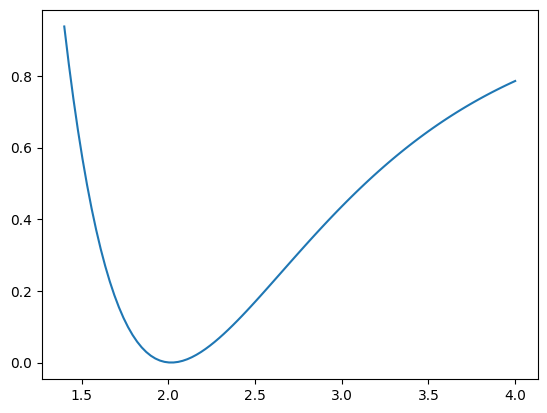

In [106]:
rGrid = np.linspace(1.4, 4, 100)
basicFunctionValues = basicFunctions[1][2].evaluate(rGrid)

plt.plot(rGrid, basicFunctionValues)